**Core Library Imports**

In [1]:
#Core data handling
import pandas as pd
import numpy as np

#Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

#Statistical analysis
from statsmodels.tsa.stattools import acf

#Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

**Set Plot Style**

In [3]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

**Define Project Paths**

In [7]:
#Base paths
DATA_PATH = "/content/hadukgrid_rainfall_2025.csv"

print("Data path set to:", DATA_PATH)

Data path set to: /content/hadukgrid_rainfall_2025.csv


**Load the Dataset**

In [10]:
#Load dataset
df = pd.read_csv(DATA_PATH)
df.shape

FileNotFoundError: [Errno 2] No such file or directory: '/content/hadukgrid_rainfall_2025.csv'

In [8]:
list(df.columns)

['time',
 'projection_y_coordinate',
 'projection_x_coordinate',
 'rainfall_mm',
 'latitude',
 'longitude',
 'day_of_year',
 'month',
 'week_of_year',
 'season',
 'rain_lag_1',
 'rain_lag_3',
 'rain_lag_7',
 'rain_rollsum_7',
 'rain_rollsum_30']

In [9]:
#Convert time column to datetime
df["time"] = pd.to_datetime(df["time"])

#Convert categorical column
df["season"] = df["season"].astype("category")

#Ensure numeric columns are numeric
numeric_cols = [
    "rainfall_mm",
    "latitude",
    "longitude",
    "projection_x_coordinate",
    "projection_y_coordinate",
    "rain_lag_1",
    "rain_lag_3",
    "rain_lag_7",
    "rain_rollsum_7",
    "rain_rollsum_30",
    "day_of_year",
    "week_of_year",
    "month"
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

In [10]:
#Sort by location (lat,lon) and time
df = df.sort_values(
    by=["latitude", "longitude", "time"]
).reset_index(drop=True)

print("Data sorted by spatial location and time")

Data sorted by spatial location and time


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156088 entries, 0 to 156087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   time                     156088 non-null  datetime64[ns]
 1   projection_y_coordinate  156088 non-null  float64       
 2   projection_x_coordinate  156088 non-null  float64       
 3   rainfall_mm              156088 non-null  float64       
 4   latitude                 156088 non-null  float64       
 5   longitude                156088 non-null  float64       
 6   day_of_year              156088 non-null  int64         
 7   month                    156088 non-null  int64         
 8   week_of_year             156088 non-null  int64         
 9   season                   156088 non-null  category      
 10  rain_lag_1               156088 non-null  float64       
 11  rain_lag_3               156088 non-null  float64       
 12  rain_lag_7      

In [12]:
df.head()

,time,projection_y_coordinate,projection_x_coordinate,rainfall_mm,latitude,longitude,day_of_year,month,week_of_year,season,rain_lag_1,rain_lag_3,rain_lag_7,rain_rollsum_7,rain_rollsum_30
0,2025-01-08 12:00:00,37500.0,162500.0,10.528320,50.189194,-5.327663,8,1,2,Winter,1.245117,15.820312,13.156250,76.500000,89.656250
1,2025-01-09 12:00:00,37500.0,162500.0,4.671875,50.189194,-5.327663,9,1,2,Winter,10.528320,7.914062,0.057617,81.114258,94.328125
2,2025-01-10 12:00:00,37500.0,162500.0,3.799805,50.189194,-5.327663,10,1,2,Winter,4.671875,1.245117,0.398438,84.515625,98.127930
3,2025-01-11 12:00:00,37500.0,162500.0,2.021484,50.189194,-5.327663,11,1,2,Winter,3.799805,10.528320,40.536133,46.000977,100.149414
4,2025-01-12 12:00:00,37500.0,162500.0,0.019531,50.189194,-5.327663,12,1,2,Winter,2.021484,4.671875,15.820312,30.200195,100.168945


**Data Integrity & Quality Checks**

In [13]:
#Check missing values per column
missing_summary = df.isnull().sum()

missing_summary

,0
time,0
projection_y_coordinate,0
projection_x_coordinate,0
rainfall_mm,0
latitude,0
longitude,0
day_of_year,0
month,0
week_of_year,0
season,0


In [14]:
#Check duplicate rows
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(0)

In [15]:
#Overall temporal coverage
df["time"].min(), df["time"].max()

(Timestamp('2025-01-08 12:00:00'), Timestamp('2025-12-31 12:00:00'))

In [16]:
#Number of records per grid cell
records_per_location = (
    df.groupby(["latitude", "longitude"])
      .size()
      .describe()
)

records_per_location

,0
count,436.0
mean,358.0
std,0.0
min,358.0
25%,358.0
50%,358.0
75%,358.0
max,358.0


In [17]:
#Basic rainfall validity checks
df["rainfall_mm"].describe()

,rainfall_mm
count,156088.000000
mean,2.839359
std,5.695600
min,0.000000
25%,0.006836
50%,0.314453
75%,3.008789
max,87.786133


In [18]:
#Check for invalid rainfall values
(df["rainfall_mm"] < 0).sum()

np.int64(0)

In [19]:
df[[
    "rain_lag_1",
    "rain_lag_3",
    "rain_lag_7",
    "rain_rollsum_7",
    "rain_rollsum_30"
]].describe()

,rain_lag_1,rain_lag_3,rain_lag_7,rain_rollsum_7,rain_rollsum_30
count,156088.000000,156088.000000,156088.000000,156088.000000,156088.000000
mean,2.836318,2.882898,2.920179,20.122179,84.199458
std,5.693996,5.763599,5.794955,23.247575,66.886195
min,0.000000,0.000000,0.000000,0.000000,0.015625
25%,0.006836,0.007812,0.008789,2.869141,35.120117
50%,0.313477,0.327148,0.352539,12.476562,65.067383
75%,3.001953,3.064453,3.135986,29.196289,115.654297
max,87.786133,87.786133,87.786133,229.845703,546.711914


**EDA(Exploratory Data Analysis)**

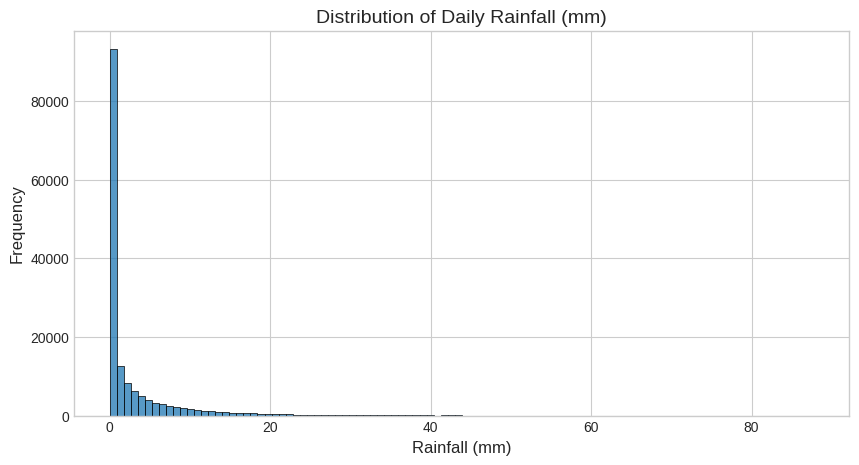

In [20]:
#Histogram of daily rainfall
plt.figure()
sns.histplot(df["rainfall_mm"], bins=100, kde=False)
plt.title("Distribution of Daily Rainfall (mm)")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

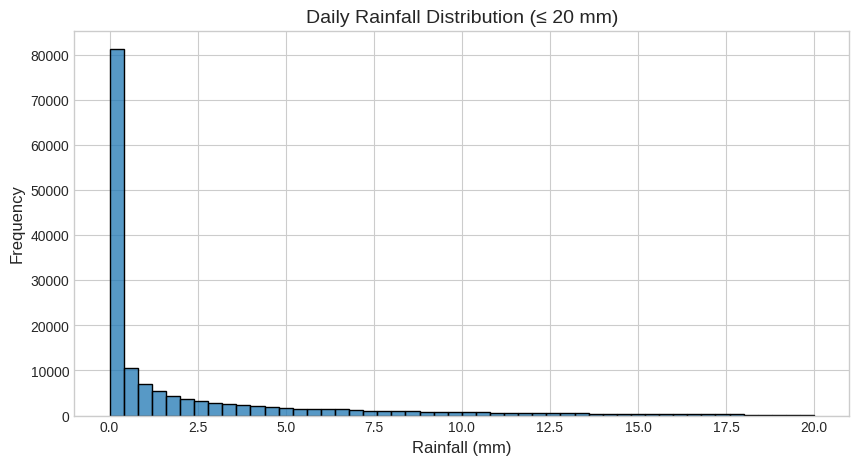

In [21]:
#Focus on rainfall <= 20 mm
plt.figure()
sns.histplot(df[df["rainfall_mm"] <= 20]["rainfall_mm"], bins=50)
plt.title("Daily Rainfall Distribution (≤ 20 mm)")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

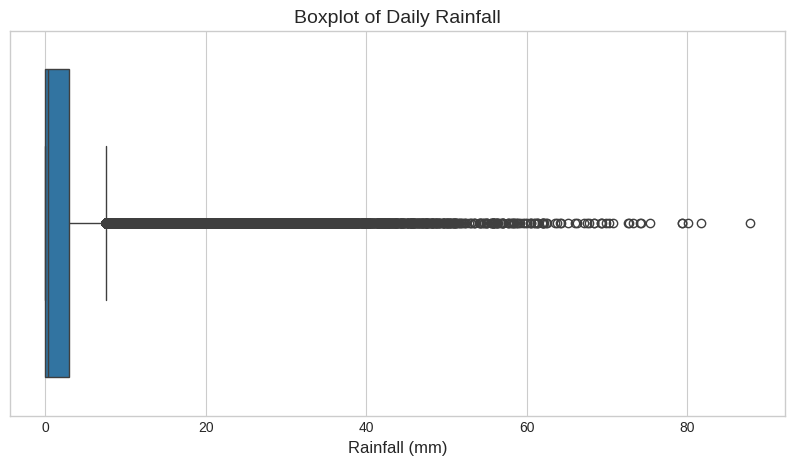

In [22]:
plt.figure()
sns.boxplot(x=df["rainfall_mm"])
plt.title("Boxplot of Daily Rainfall")
plt.xlabel("Rainfall (mm)")
plt.show()

In [23]:
#Percentage of dry days
zero_rain_pct = (df["rainfall_mm"] == 0).mean() * 100
zero_rain_pct

np.float64(15.842345343652298)

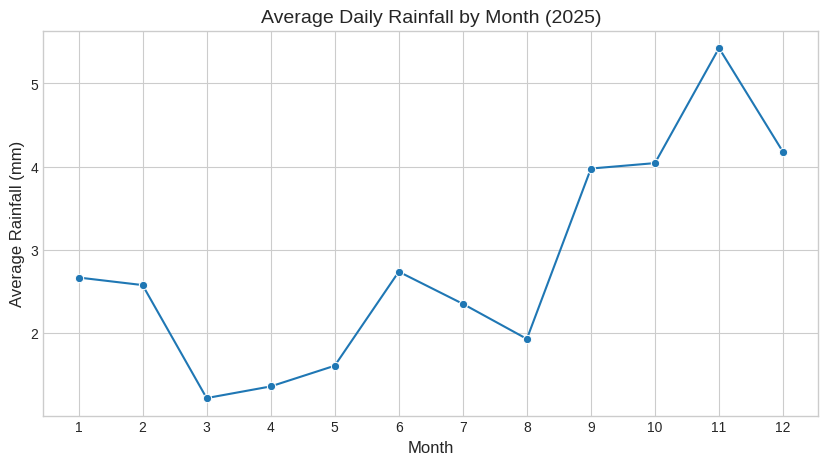

In [24]:
#Monthly average rainfall
monthly_avg = (
    df.groupby("month")["rainfall_mm"]
      .mean()
      .reset_index()
)

plt.figure()
sns.lineplot(data=monthly_avg, x="month", y="rainfall_mm", marker="o")
plt.title("Average Daily Rainfall by Month (2025)")
plt.xlabel("Month")
plt.ylabel("Average Rainfall (mm)")
plt.xticks(range(1, 13))
plt.show()

/tmp/ipython-input-2828595351.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("season")["rainfall_mm"]


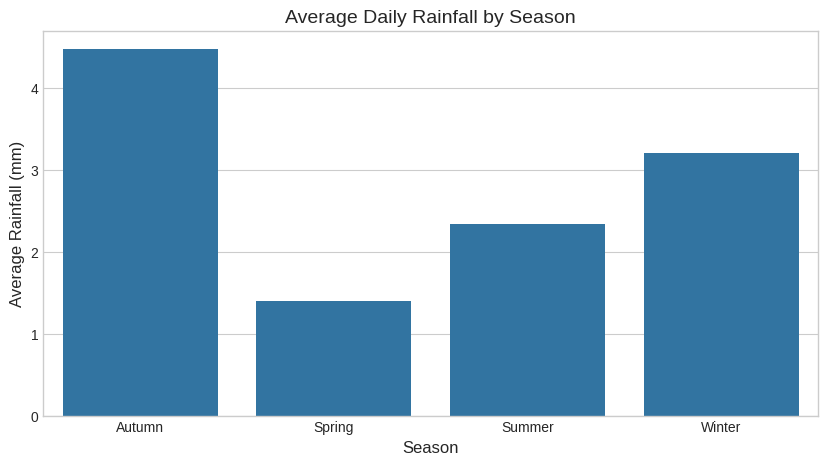

In [26]:
#Seasonal average rainfall
seasonal_avg = (
    df.groupby("season")["rainfall_mm"]
      .mean()
      .reset_index()
)

plt.figure()
sns.barplot(data=seasonal_avg, x="season", y="rainfall_mm")
plt.title("Average Daily Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Average Rainfall (mm)")
plt.show()

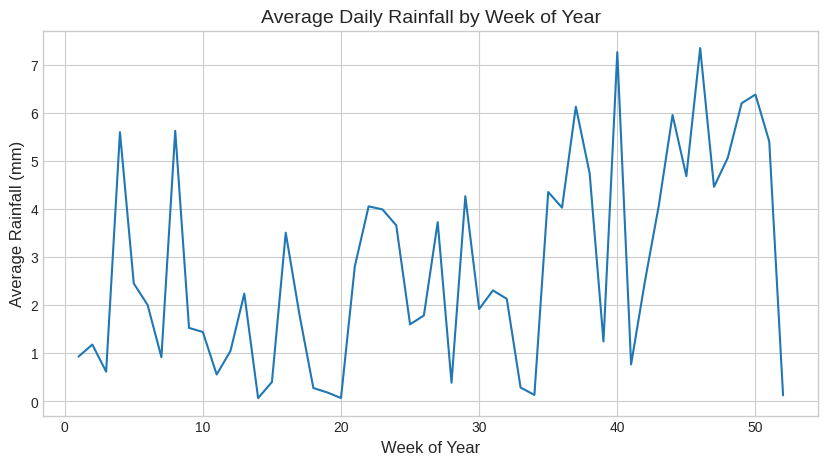

In [27]:
weekly_avg = (
    df.groupby("week_of_year")["rainfall_mm"]
      .mean()
      .reset_index()
)

plt.figure()
sns.lineplot(data=weekly_avg, x="week_of_year", y="rainfall_mm")
plt.title("Average Daily Rainfall by Week of Year")
plt.xlabel("Week of Year")
plt.ylabel("Average Rainfall (mm)")
plt.show()

In [29]:
spatial_mean = (
    df.groupby(["latitude", "longitude"])["rainfall_mm"]
      .mean()
      .reset_index()
)

spatial_mean.describe()

,latitude,longitude,rainfall_mm
count,436.000000,436.000000,436.000000
mean,54.129810,-2.939201,2.839359
std,2.366055,2.106004,1.459657
min,50.189194,-7.999914,1.045099
25%,52.034215,-4.321046,1.680779
50%,54.048415,-2.947188,2.408780
75%,55.899973,-1.441295,3.616737
max,60.569832,1.530286,8.142938


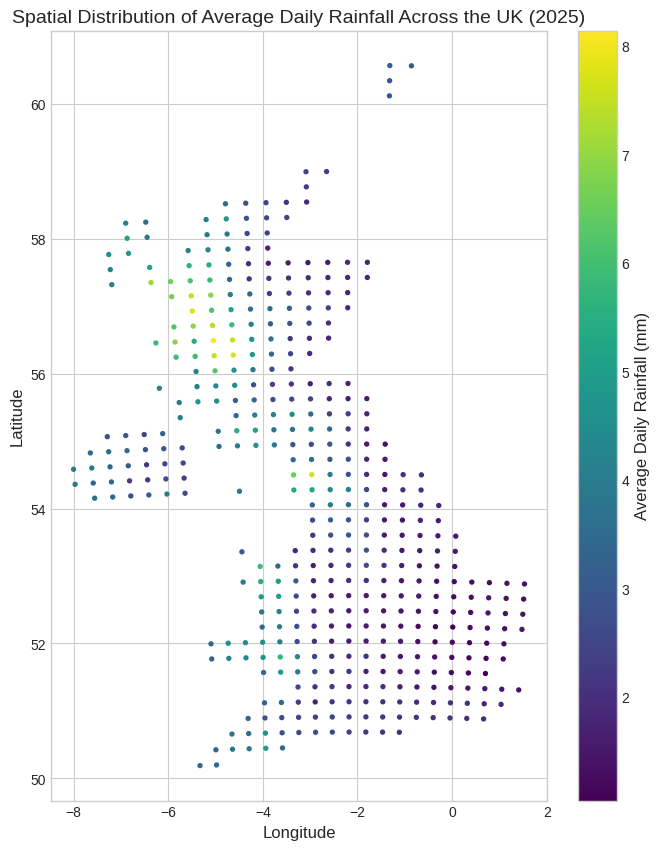

In [31]:
plt.figure(figsize=(8, 10))
plt.scatter(
    spatial_mean["longitude"],
    spatial_mean["latitude"],
    c=spatial_mean["rainfall_mm"],
    cmap="viridis",
    s=8
)
plt.colorbar(label="Average Daily Rainfall (mm)")
plt.title("Spatial Distribution of Average Daily Rainfall Across the UK (2025)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [32]:
spatial_mean["latitude"].corr(spatial_mean["rainfall_mm"])

np.float64(0.3639102659394039)

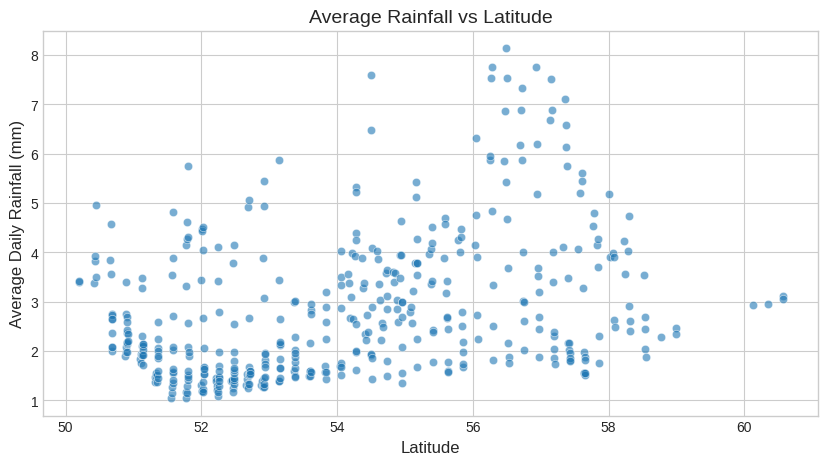

In [33]:
plt.figure()
sns.scatterplot(
    x=spatial_mean["latitude"],
    y=spatial_mean["rainfall_mm"],
    alpha=0.6
)
plt.title("Average Rainfall vs Latitude")
plt.xlabel("Latitude")
plt.ylabel("Average Daily Rainfall (mm)")
plt.show()

In [34]:
df["lat_band"] = pd.cut(df["latitude"], bins=5)

lat_band_stats = (
    df.groupby("lat_band")["rainfall_mm"]
      .mean()
      .reset_index()
)

lat_band_stats

/tmp/ipython-input-673290587.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("lat_band")["rainfall_mm"]


,lat_band,rainfall_mm
0,"(50.179, 52.265]",2.308627
1,"(52.265, 54.341]",2.281256
2,"(54.341, 56.418]",3.332107
3,"(56.418, 58.494]",3.839634
4,"(58.494, 60.57]",2.643610


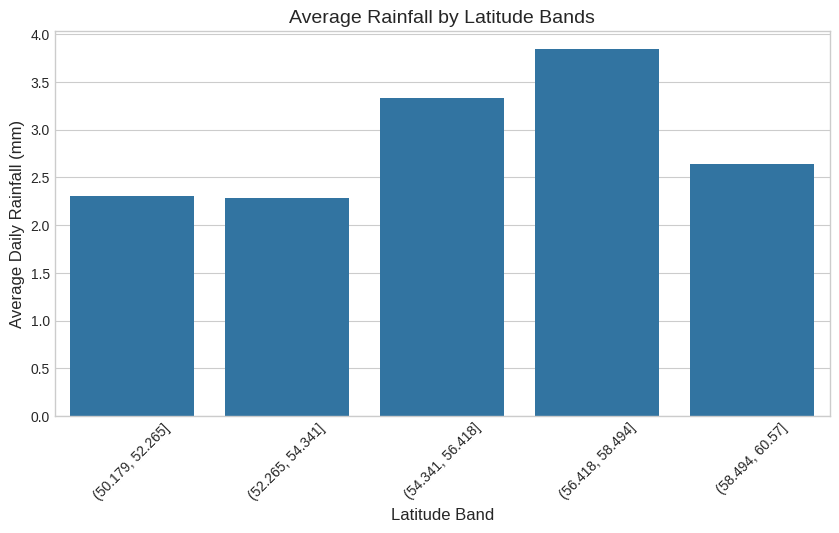

In [35]:
plt.figure()
sns.barplot(data=lat_band_stats, x="lat_band", y="rainfall_mm")
plt.title("Average Rainfall by Latitude Bands")
plt.xlabel("Latitude Band")
plt.ylabel("Average Daily Rainfall (mm)")
plt.xticks(rotation=45)
plt.show()

In [36]:
#Correlation of target with persistence features
features = [
    "rain_lag_1",
    "rain_lag_3",
    "rain_lag_7",
    "rain_rollsum_7",
    "rain_rollsum_30"
]

corr_with_target = df[features + ["rainfall_mm"]].corr()["rainfall_mm"].sort_values(ascending=False)
corr_with_target

,rainfall_mm
rainfall_mm,1.000000
rain_rollsum_7,0.525020
rain_rollsum_30,0.348417
rain_lag_1,0.337718
rain_lag_3,0.207322
rain_lag_7,0.103298


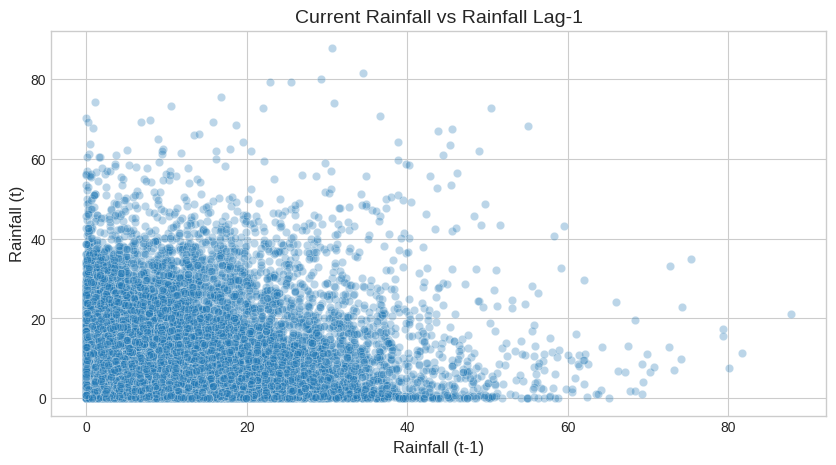

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.scatterplot(x=df["rain_lag_1"], y=df["rainfall_mm"], alpha=0.3)
plt.title("Current Rainfall vs Rainfall Lag-1")
plt.xlabel("Rainfall (t-1)")
plt.ylabel("Rainfall (t)")
plt.show()